# Jerk-GNN — 2D Spring-Mass System

Extension of the 1D Jerk-GNN to 2D. Bodies move in the plane; springs exert Hooke-law forces along the displacement vector.

**Key differences from 1D:**
- State: position/velocity/acceleration/jerk are all 2D vectors per body
- Analytic jerk involves both relative position and relative velocity (direction matters)
- GNN node features: flattened 2D position history + 2D v₀ + 2D a₀
- Output head: 2D jerk per node
- Closer analogy to fish data (same 2D vector structure)

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch_geometric.nn import MessagePassing
from scipy.integrate import solve_ivp

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

/projectnb/depaqlab/bddepasq/spring-mass/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


In [2]:
# ── 2D Spring-Mass Simulator ──────────────────────────────────────────────────

class SpringMassSystem2D:
    """
    N bodies connected by springs in 2D.

    Force on body i from body j:
        F_ij = k_ij * (|r_ij| - l_ij) * r_hat_ij
    where r_ij = x_j - x_i,  r_hat_ij = r_ij / |r_ij|

    Analytic jerk (exact, from d/dt of EOM):
        j_i = (1/m_i) * sum_j k_ij * d/dt[(|r_ij| - l_ij) * r_hat_ij]

    where d/dt[(s-l)*r/s] = (r·v)*r/s² + (s-l)*v/s - (s-l)*(r·v)*r/s³
    with s = |r|, v = v_j - v_i
    """

    def __init__(self, n_bodies=6, seed=42):
        rng = np.random.default_rng(seed)
        self.n = n_bodies

        # masses
        self.masses = rng.uniform(0.5, 2.0, n_bodies)

        # place bodies on a circle as equilibrium positions
        angles = np.linspace(0, 2 * np.pi, n_bodies, endpoint=False)
        radius = 3.0
        self.eq_pos = np.stack([radius * np.cos(angles),
                                 radius * np.sin(angles)], axis=1)  # (n, 2)

        # spring connectivity — same structure as 1D
        K = np.zeros((n_bodies, n_bodies))
        for i in range(n_bodies):
            for j in range(i + 1, n_bodies):
                if rng.random() < 0.6:
                    k = rng.uniform(0.5, 3.0)
                    K[i, j] = k
                    K[j, i] = k
        # chain backbone so no isolated nodes
        for i in range(n_bodies - 1):
            if K[i, i + 1] == 0:
                k = rng.uniform(0.5, 3.0)
                K[i, i + 1] = k
                K[i + 1, i] = k
        self.K = K

        # natural lengths = equilibrium inter-body distances (+ small noise)
        L = np.zeros((n_bodies, n_bodies))
        for i in range(n_bodies):
            for j in range(n_bodies):
                if K[i, j] > 0:
                    L[i, j] = (np.linalg.norm(self.eq_pos[j] - self.eq_pos[i])
                                + rng.uniform(-0.1, 0.1))
        self.L = L

        # GNN edge index and edge attributes
        edges = [(i, j) for i in range(n_bodies)
                         for j in range(n_bodies) if K[i, j] > 0]
        self.edge_index = torch.tensor(edges, dtype=torch.long).T   # (2, E)
        self.edge_attr  = torch.tensor(
            [K[i, j] for i, j in edges], dtype=torch.float32
        ).unsqueeze(1)                                               # (E, 1)

    # ── ODE ──────────────────────────────────────────────────────────────────
    def ode(self, t, state):
        x = state[:2 * self.n].reshape(self.n, 2)
        v = state[2 * self.n:].reshape(self.n, 2)
        a = np.zeros((self.n, 2))
        for i in range(self.n):
            for j in range(self.n):
                if self.K[i, j] > 0:
                    r = x[j] - x[i]
                    dist = np.linalg.norm(r)
                    if dist > 1e-10:
                        a[i] += self.K[i, j] * (dist - self.L[i, j]) * r / (dist * self.masses[i])
        return np.concatenate([v.flatten(), a.flatten()])

    # ── Analytic jerk ─────────────────────────────────────────────────────────
    def analytic_jerk(self, x, v):
        """
        Exact 2D jerk via time-derivative of EOM.
        d/dt[(s-l)*r/s] = (r·v)*r/s² + (s-l)*v/s - (s-l)*(r·v)*r/s³
        """
        j = np.zeros((self.n, 2))
        for i in range(self.n):
            for k in range(self.n):
                if self.K[i, k] > 0:
                    r  = x[k] - x[i]          # relative position (2,)
                    dv = v[k] - v[i]           # relative velocity  (2,)
                    s  = np.linalg.norm(r)
                    if s < 1e-10:
                        continue
                    l   = self.L[i, k]
                    rdv = np.dot(r, dv)
                    dF  = (rdv * r / s**2
                           + (s - l) * dv / s
                           - (s - l) * rdv * r / s**3)
                    j[i] += self.K[i, k] * dF / self.masses[i]
        return j  # (n, 2)

    # ── Simulate ──────────────────────────────────────────────────────────────
    def simulate(self, T=20.0, dt=0.05, x0=None, v0=None):
        rng = np.random.default_rng()
        if x0 is None:
            x0 = self.eq_pos + rng.uniform(-0.5, 0.5, (self.n, 2))
        if v0 is None:
            v0 = rng.uniform(-1.0, 1.0, (self.n, 2))

        t_span = (0, T)
        t_eval = np.arange(0, T, dt)
        sol = solve_ivp(
            self.ode, t_span,
            np.concatenate([x0.flatten(), v0.flatten()]),
            t_eval=t_eval, method='RK45', rtol=1e-8, atol=1e-10
        )
        x_traj = sol.y[:2 * self.n].T.reshape(-1, self.n, 2)   # (T, n, 2)
        v_traj = sol.y[2 * self.n:].T.reshape(-1, self.n, 2)   # (T, n, 2)
        return x_traj, v_traj, t_eval


system = SpringMassSystem2D(n_bodies=6)
print(f'Spring constant matrix K:\n{np.round(system.K, 2)}')
print(f'Mass vector: {np.round(system.masses, 2)}')
print(f'Edges: {system.edge_index.shape[1]}')

Spring constant matrix K:
[[0.   0.61 0.   1.63 2.82 0.  ]
 [0.61 0.   0.89 1.07 0.66 0.  ]
 [0.   0.89 0.   2.21 0.   2.93]
 [1.63 1.07 2.21 0.   2.36 0.  ]
 [2.82 0.66 0.   2.36 0.   1.67]
 [0.   0.   2.93 0.   1.67 0.  ]]
Mass vector: [1.66 1.16 1.79 1.55 0.64 1.96]
Edges: 20


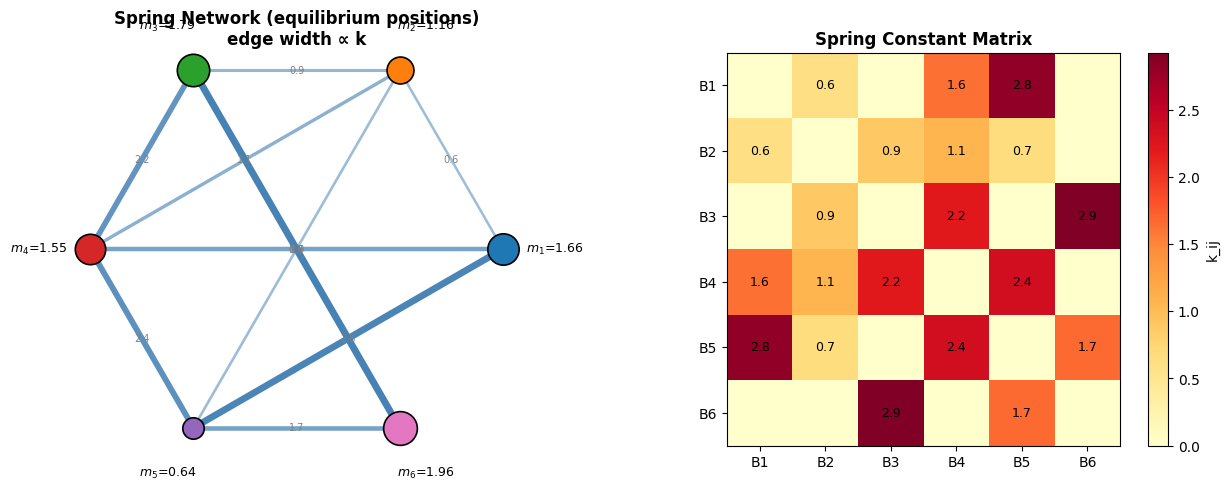

In [3]:
# ── System Visualization ──────────────────────────────────────────────────────
colors6 = plt.cm.tab10(np.linspace(0, 0.6, 6))
pos = system.eq_pos
k_max = system.K.max()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
for i in range(6):
    for j in range(i + 1, 6):
        if system.K[i, j] > 0:
            lw    = 1 + 4 * system.K[i, j] / k_max
            alpha = 0.4 + 0.6 * system.K[i, j] / k_max
            ax.plot([pos[i, 0], pos[j, 0]], [pos[i, 1], pos[j, 1]],
                    color='steelblue', linewidth=lw, alpha=alpha, zorder=1)
            mid = (pos[i] + pos[j]) / 2
            ax.text(mid[0], mid[1], f'{system.K[i,j]:.1f}',
                    fontsize=7, ha='center', va='center', color='gray')
for i in range(6):
    sz = 200 + 400 * (system.masses[i] - 0.5) / 1.5
    ax.scatter(*pos[i], s=sz, color=colors6[i], zorder=3, edgecolors='k', linewidth=1.2)
    ax.text(pos[i, 0] * 1.25, pos[i, 1] * 1.25,
            f'$m_{i+1}$={system.masses[i]:.2f}', fontsize=9, ha='center', va='center')
ax.set_aspect('equal'); ax.axis('off')
ax.set_title('Spring Network (equilibrium positions)\nedge width ∝ k', fontweight='bold')

ax2 = axes[1]
im = ax2.imshow(system.K, cmap='YlOrRd')
plt.colorbar(im, ax=ax2, label='k_ij')
for i in range(6):
    for j in range(6):
        if system.K[i, j] > 0:
            ax2.text(j, i, f'{system.K[i,j]:.1f}', ha='center', va='center', fontsize=9)
ax2.set_xticks(range(6)); ax2.set_yticks(range(6))
ax2.set_xticklabels([f'B{i+1}' for i in range(6)])
ax2.set_yticklabels([f'B{i+1}' for i in range(6)])
ax2.set_title('Spring Constant Matrix', fontweight='bold')

plt.tight_layout()
plt.savefig('png/2d_topo.png', dpi=150, bbox_inches='tight')
plt.show()

In [4]:
# ── Dataset ───────────────────────────────────────────────────────────────────
DT           = 0.05
HISTORY      = 5
N_TRAJ_TRAIN = 40
N_TRAJ_TEST  = 10
T_TRAIN      = 15.0
T_TEST       = 20.0
JERK_WEIGHT  = 1.0


def finite_diff_va_2d(x_traj, dt):
    """Central finite differences for v and a on (T, n, 2) trajectory."""
    v = np.gradient(x_traj, dt, axis=0)
    a = np.gradient(v,      dt, axis=0)
    return v, a


def build_dataset(system, n_traj, T, dt, history_len):
    dataset = []
    for _ in range(n_traj):
        x_traj, v_traj, _ = system.simulate(T=T, dt=dt)
        _, a_traj = finite_diff_va_2d(x_traj, dt)
        T_steps = x_traj.shape[0]

        for t in range(history_len, T_steps - 1):
            # x_hist: (n, history, 2) → flatten to (n, history*2)
            x_hist = torch.tensor(
                x_traj[t - history_len:t].transpose(1, 0, 2).reshape(system.n, -1),
                dtype=torch.float32
            )  # (n, history*2)
            v0       = torch.tensor(v_traj[t], dtype=torch.float32)   # (n, 2)
            a0       = torch.tensor(a_traj[t], dtype=torch.float32)   # (n, 2)
            x_target = torch.tensor(x_traj[t + 1], dtype=torch.float32)  # (n, 2)
            j_target = torch.tensor(
                system.analytic_jerk(x_traj[t], v_traj[t]), dtype=torch.float32
            )  # (n, 2)

            dataset.append((x_hist, a0, v0, x_target, j_target))
    return dataset


print('Simulating training data...')
train_data = build_dataset(system, N_TRAJ_TRAIN, T_TRAIN, DT, HISTORY)
print('Simulating test data...')
test_data  = build_dataset(system, N_TRAJ_TEST,  T_TEST,  DT, HISTORY)
print(f'Train samples: {len(train_data)}  |  Test samples: {len(test_data)}')

Simulating training data...
Simulating test data...
Train samples: 11760  |  Test samples: 3940


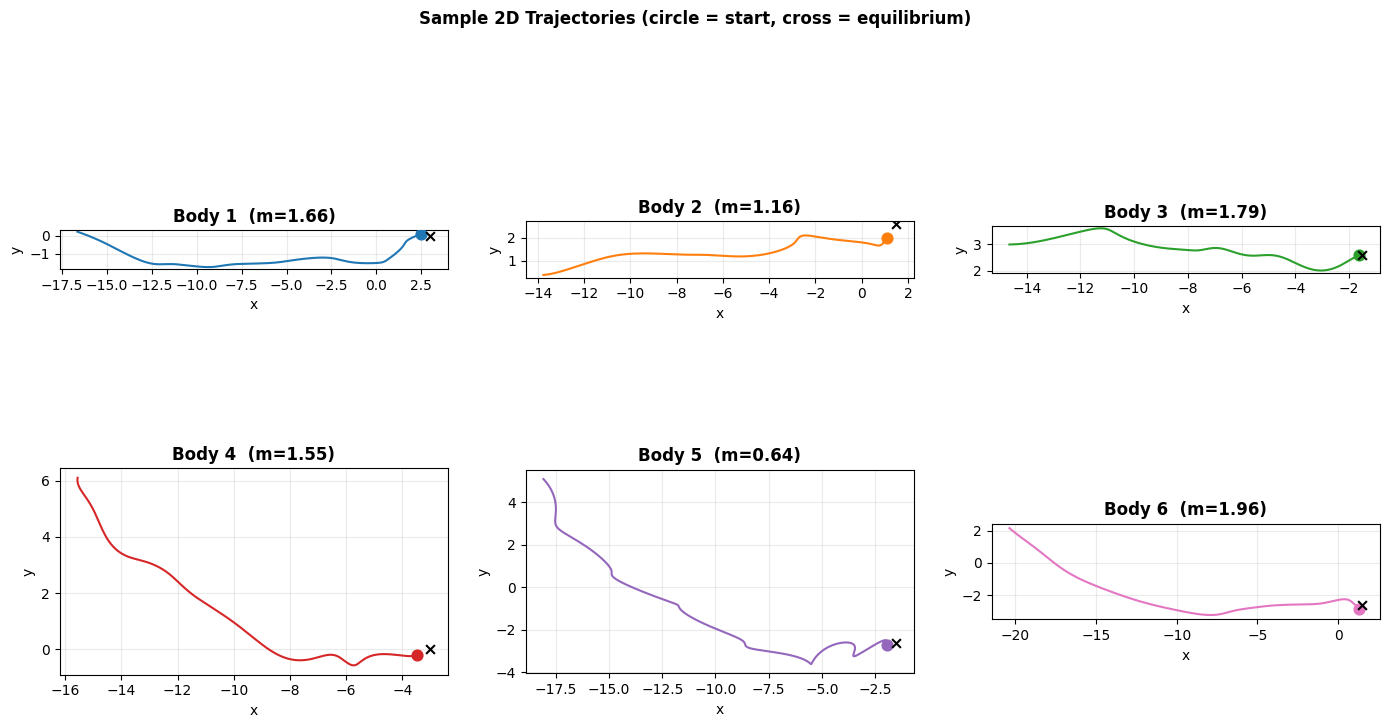

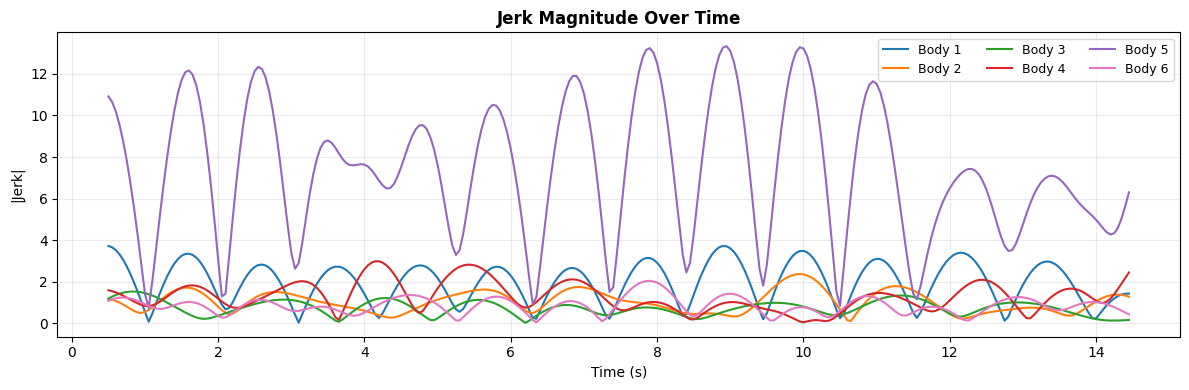

In [5]:
# ── Sample Trajectory Visualization ──────────────────────────────────────────
x_sample, v_sample, t_sample = system.simulate(T=15.0, dt=DT)
_, a_sample = finite_diff_va_2d(x_sample, DT)
j_sample = np.array([
    system.analytic_jerk(x_sample[t], v_sample[t])
    for t in range(len(t_sample))
])  # (T, n, 2)

TRIM = 10
sl = slice(TRIM, -TRIM)

# 2D trajectories
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
for i in range(6):
    ax = axes[i]
    ax.plot(x_sample[sl, i, 0], x_sample[sl, i, 1], color=colors6[i], lw=1.5)
    ax.scatter(*x_sample[TRIM, i], color=colors6[i], s=60, zorder=5, marker='o')
    ax.scatter(*system.eq_pos[i], color='k', s=40, zorder=5, marker='x')
    ax.set_title(f'Body {i+1}  (m={system.masses[i]:.2f})', fontweight='bold')
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.set_aspect('equal'); ax.grid(True, alpha=0.25)
plt.suptitle('Sample 2D Trajectories (circle = start, cross = equilibrium)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('png/2d_traj.png', dpi=150, bbox_inches='tight')
plt.show()

# Jerk magnitude over time
j_mag = np.linalg.norm(j_sample[sl], axis=-1)  # (T, n)
fig, ax = plt.subplots(figsize=(12, 4))
for i in range(6):
    ax.plot(t_sample[sl], j_mag[:, i], color=colors6[i],
            lw=1.5, label=f'Body {i+1}')
ax.set_xlabel('Time (s)'); ax.set_ylabel('|Jerk|')
ax.set_title('Jerk Magnitude Over Time', fontweight='bold')
ax.legend(ncol=3, fontsize=9); ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

In [6]:
# ── Model Architecture ────────────────────────────────────────────────────────

class JerkMessagePassing2D(MessagePassing):
    """
    Message passing layer for 2D jerk prediction.
    Identical structure to 1D version; node_dim now encodes 2D history.
    """
    def __init__(self, node_dim, edge_dim, hidden_dim):
        super().__init__(aggr='sum')
        self.message_net = nn.Sequential(
            nn.Linear(2 * node_dim + edge_dim, hidden_dim), nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),              nn.Tanh(),
        )
        self.update_net = nn.Sequential(
            nn.Linear(node_dim + hidden_dim, hidden_dim), nn.Tanh(),
            nn.Linear(hidden_dim, node_dim),              nn.Tanh(),
        )

    def forward(self, x, edge_index, edge_attr):
        return self.propagate(edge_index, x=x, edge_attr=edge_attr)

    def message(self, x_i, x_j, edge_attr):
        return self.message_net(torch.cat([x_i, x_j, edge_attr], dim=-1))

    def update(self, aggr_out, x):
        return self.update_net(torch.cat([x, aggr_out], dim=-1))


class JerkGNN2D(nn.Module):
    """
    2D Jerk-GNN: predicts jerk vector (2D) per node;
    integrates analytically to get a, v, x_next (all 2D).

    Node features: [x_hist_flat(history*2), v0(2), a0(2)]  →  hidden_dim
    Output: jerk (2D per node)
    Integration (constant-jerk Taylor, O(dt⁴)):
        x_next = x + v*dt + 0.5*a*dt² + (1/6)*j*dt³
        v_next = v + a*dt + 0.5*j*dt²
        a_next = a + j*dt
    """

    def __init__(self, n_bodies, history_len, hidden_dim=64, n_layers=3):
        super().__init__()
        self.n = n_bodies
        # history*2 (flattened xy) + 2 (v) + 2 (a) = history*2 + 4
        node_input_dim = history_len * 2 + 4
        edge_dim       = 1   # spring constant

        self.input_proj = nn.Linear(node_input_dim, hidden_dim)
        self.layers = nn.ModuleList([
            JerkMessagePassing2D(hidden_dim, edge_dim, hidden_dim)
            for _ in range(n_layers)
        ])
        # output: 2D jerk per node
        self.jerk_head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2), nn.Tanh(),
            nn.Linear(hidden_dim // 2, 2)
        )

    def forward(self, x_hist, a0, v0, edge_index, edge_attr, dt):
        """
        x_hist:     (B*n, history*2)  — flattened 2D position history
        a0, v0:     (B*n, 2)
        edge_index: (2, E)
        edge_attr:  (E, 1)
        Returns: x_next, a_next, v_next  — all (B*n, 2)
                 j                       — (B*n, 2)
        """
        node_feat = torch.cat([x_hist, v0, a0], dim=-1)   # (B*n, history*2+4)
        h = torch.tanh(self.input_proj(node_feat))

        for layer in self.layers:
            h = h + layer(h, edge_index, edge_attr)        # residual

        j = self.jerk_head(h)                              # (B*n, 2)

        # hard consistency integration (constant-jerk Taylor)
        x0 = x_hist[:, -2:]   # last 2 elements = current position (x, y)
        a_next = a0 + j * dt
        v_next = v0 + a0 * dt + 0.5 * j * dt**2
        x_next = x0 + v0 * dt + 0.5 * a0 * dt**2 + (1/6) * j * dt**3

        return x_next, a_next, v_next, j


model = JerkGNN2D(
    n_bodies=6, history_len=HISTORY, hidden_dim=64, n_layers=3
).to(device)
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

Parameters: 77,794


In [ ]:
# ── Training ──────────────────────────────────────────────────────────────────

def collate_batch(batch, system, device):
    B = len(batch)
    n = system.n
    x_hists, a0s, v0s, targets, j_targets = zip(*batch)

    x_hist   = torch.cat(x_hists, dim=0).to(device)          # (B*n, history*2)
    a0       = torch.cat(a0s,     dim=0).to(device)          # (B*n, 2)
    v0       = torch.cat(v0s,     dim=0).to(device)          # (B*n, 2)
    target   = torch.cat(targets, dim=0).to(device)          # (B*n, 2)
    j_target = torch.cat(j_targets, dim=0).to(device)        # (B*n, 2)

    ei = system.edge_index
    ea = system.edge_attr
    edge_index = torch.cat([ei + i * n for i in range(B)], dim=1).to(device)
    edge_attr  = ea.repeat(B, 1).to(device)

    return x_hist, a0, v0, target, j_target, edge_index, edge_attr


def train(model, train_data, test_data, system,
          n_epochs=100, batch_size=256, lr=1e-3, jerk_weight=1.0):

    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, n_epochs)
    criterion = nn.MSELoss()

    train_losses, test_losses = [], []
    pos_losses, jerk_losses   = [], []

    for epoch in range(n_epochs):
        model.train()
        ep_loss = ep_pos = ep_jerk = 0.0

        idx     = torch.randperm(len(train_data))
        batches = [list(idx[i:i+batch_size].numpy())
                   for i in range(0, len(train_data), batch_size)]

        for batch_idx in batches:
            batch = [train_data[i] for i in batch_idx]
            x_hist, a0, v0, target, j_target, edge_index, edge_attr = \
                collate_batch(batch, system, device)

            optimizer.zero_grad()
            x_next, _, _, j_pred = model(x_hist, a0, v0, edge_index, edge_attr, DT)

            pos_loss  = criterion(x_next, target)
            jerk_loss = criterion(j_pred, j_target)
            loss      = pos_loss + jerk_weight * jerk_loss

            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            B = len(batch_idx)
            ep_loss  += loss.item()      * B
            ep_pos   += pos_loss.item()  * B
            ep_jerk  += jerk_loss.item() * B

        scheduler.step()
        N = len(train_data)
        train_losses.append(ep_loss  / N)
        pos_losses.append(  ep_pos   / N)
        jerk_losses.append( ep_jerk  / N)

        model.eval()
        with torch.no_grad():
            val_loss = 0.0
            for i in range(0, len(test_data), batch_size):
                batch = test_data[i:i+batch_size]
                x_hist, a0, v0, target, j_target, edge_index, edge_attr = \
                    collate_batch(batch, system, device)
                x_next, _, _, j_pred = model(x_hist, a0, v0, edge_index, edge_attr, DT)
                val_loss += (criterion(x_next, target) +
                             jerk_weight * criterion(j_pred, j_target)).item() * len(batch)
            test_losses.append(val_loss / len(test_data))

        if (epoch + 1) % 10 == 0:
            print(f'Epoch {epoch+1:3d}/{n_epochs} | '
                  f'Total: {train_losses[-1]:.2e} | '
                  f'Pos: {pos_losses[-1]:.2e} | '
                  f'Jerk: {jerk_losses[-1]:.2e} | '
                  f'Test: {test_losses[-1]:.2e}')

    return train_losses, test_losses, pos_losses, jerk_losses


train_losses, test_losses, pos_losses, jerk_losses = train(
    model, train_data, test_data, system,
    n_epochs=100, batch_size=256, lr=1e-3, jerk_weight=JERK_WEIGHT
)

Epoch  10/100 | Total: 8.58e-01 | Pos: 1.88e-03 | Jerk: 8.56e-01 | Test: 1.63e+00
Epoch  20/100 | Total: 4.01e-01 | Pos: 1.88e-03 | Jerk: 3.99e-01 | Test: 1.30e+00
Epoch  30/100 | Total: 2.28e-01 | Pos: 1.88e-03 | Jerk: 2.26e-01 | Test: 1.08e+00
Epoch  40/100 | Total: 1.51e-01 | Pos: 1.88e-03 | Jerk: 1.49e-01 | Test: 9.85e-01
Epoch  50/100 | Total: 1.05e-01 | Pos: 1.88e-03 | Jerk: 1.04e-01 | Test: 9.36e-01
Epoch  60/100 | Total: 7.83e-02 | Pos: 1.88e-03 | Jerk: 7.64e-02 | Test: 8.96e-01
Epoch  70/100 | Total: 6.00e-02 | Pos: 1.88e-03 | Jerk: 5.81e-02 | Test: 8.88e-01
Epoch  80/100 | Total: 5.00e-02 | Pos: 1.88e-03 | Jerk: 4.81e-02 | Test: 8.83e-01
Epoch  90/100 | Total: 4.51e-02 | Pos: 1.88e-03 | Jerk: 4.32e-02 | Test: 8.78e-01


In [ ]:
# ── Training Curves ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].semilogy(train_losses, label='Train', lw=2)
axes[0].semilogy(test_losses,  label='Test',  lw=2, ls='--')
axes[0].set_title('Total Loss', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].semilogy(pos_losses,  color='steelblue', lw=2)
axes[1].set_title('Position Loss', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].grid(True, alpha=0.3)

axes[2].semilogy(jerk_losses, color='darkorange', lw=2)
axes[2].set_title('Jerk Loss', fontweight='bold')
axes[2].set_xlabel('Epoch'); axes[2].grid(True, alpha=0.3)

plt.suptitle('Training Curves — 2D Jerk-GNN', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('png/2d_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Final | pos: {pos_losses[-1]:.2e}  jerk: {jerk_losses[-1]:.2e}  test: {test_losses[-1]:.2e}')

In [ ]:
# ── Rollout ───────────────────────────────────────────────────────────────────

def rollout(model, system, x_traj, v_traj, a_traj, dt, history_len, device):
    """
    Autoregressive rollout.
    State: (x_window, v_t, a_t); integration: constant-jerk Taylor.
    v and a are FD-estimated from the model's own predicted x at each step.

    x_traj, v_traj, a_traj: (T, n, 2)
    Returns: x_pred (T, n, 2), j_pred (T, n, 2), j_true (T, n, 2)
    """
    model.eval()
    T, n, _ = x_traj.shape
    ei = system.edge_index.to(device)
    ea = system.edge_attr.to(device)

    x_pred_traj = np.zeros_like(x_traj)
    j_pred_traj = np.zeros_like(x_traj)
    j_true_traj = np.zeros_like(x_traj)

    x_pred_traj[:history_len] = x_traj[:history_len]
    x_window = x_traj[:history_len].copy()   # (history, n, 2)

    with torch.no_grad():
        for t in range(history_len, T - 1):
            # flatten history: (n, history*2)
            x_hist_t = torch.tensor(
                x_window.transpose(1, 0, 2).reshape(n, -1), dtype=torch.float32
            ).to(device)
            a0 = torch.tensor(a_traj[t], dtype=torch.float32).to(device)  # (n, 2)
            v0 = torch.tensor(v_traj[t], dtype=torch.float32).to(device)  # (n, 2)

            x_next, _, _, j = model(x_hist_t, a0, v0, ei, ea, dt)

            x_pred_traj[t + 1] = x_next.cpu().numpy()
            j_pred_traj[t]     = j.cpu().numpy()
            j_true_traj[t]     = system.analytic_jerk(x_traj[t], v_traj[t])

            x_window = np.roll(x_window, -1, axis=0)
            x_window[-1] = x_pred_traj[t + 1]

    return x_pred_traj, j_pred_traj, j_true_traj


x_test, v_test, t_test = system.simulate(T=T_TEST, dt=DT)
_, a_test = finite_diff_va_2d(x_test, DT)

x_pred, j_pred, j_true = rollout(
    model, system, x_test, v_test, a_test, DT, HISTORY, device
)

rmse = np.sqrt(np.mean((x_pred[HISTORY:] - x_test[HISTORY:])**2))
print(f'Rollout position RMSE: {rmse:.4f}')

In [ ]:
# ── 2D Trajectory Plots ───────────────────────────────────────────────────────
TRIM  = 10
start = HISTORY + TRIM

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i in range(6):
    ax = axes[i]
    ax.plot(x_test[start:, i, 0], x_test[start:, i, 1],
            color=colors6[i], lw=1.5, label='True')
    ax.plot(x_pred[start:, i, 0], x_pred[start:, i, 1],
            color=colors6[i], lw=1.5, ls='--', alpha=0.8, label='Predicted')
    ax.scatter(*x_test[start, i], color=colors6[i], s=50, zorder=5)
    ax.set_title(f'Body {i+1}  (m={system.masses[i]:.2f})', fontweight='bold')
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.set_aspect('equal'); ax.grid(True, alpha=0.25)
    if i == 0:
        ax.legend(fontsize=9)

plt.suptitle(f'2D Rollout: True vs Predicted  (RMSE={rmse:.4f})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('png/2d_rollout_traj.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Position Error Over Time ──────────────────────────────────────────────────
t_plot = t_test[start:]
pos_err_mean = np.sqrt(np.mean((x_pred[start:] - x_test[start:])**2, axis=(1, 2)))
per_body_err = np.sqrt(np.mean((x_pred[start:] - x_test[start:])**2, axis=-1))  # (T, n)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(t_plot, pos_err_mean, color='steelblue', lw=2)
axes[0].set_xlabel('Time (s)'); axes[0].set_ylabel('Position RMSE')
axes[0].set_title('Mean Position Error vs Rollout Time', fontweight='bold')
axes[0].grid(True, alpha=0.3)

for i in range(6):
    axes[1].plot(t_plot, per_body_err[:, i], color=colors6[i],
                 lw=1.5, label=f'Body {i+1}')
axes[1].set_xlabel('Time (s)'); axes[1].set_ylabel('Position RMSE')
axes[1].set_title('Per-Body Position Error', fontweight='bold')
axes[1].legend(ncol=3, fontsize=9); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('png/2d_error.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Jerk Correlation ──────────────────────────────────────────────────────────
# Compare predicted vs analytic jerk magnitude and components
from scipy.stats import pearsonr

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for i in range(6):
    jt_mag = np.linalg.norm(j_true[start:, i], axis=-1)
    jp_mag = np.linalg.norm(j_pred[start:, i], axis=-1)
    r, _   = pearsonr(jt_mag, jp_mag)

    axes[i].scatter(jt_mag, jp_mag, alpha=0.3, s=6, color=colors6[i])
    lims = [min(jt_mag.min(), jp_mag.min()), max(jt_mag.max(), jp_mag.max())]
    axes[i].plot(lims, lims, 'k--', lw=1)
    axes[i].set_title(f'Body {i+1}  (r={r:.3f})', fontweight='bold')
    axes[i].set_xlabel('True |jerk|'); axes[i].set_ylabel('Pred |jerk|')
    axes[i].grid(True, alpha=0.25)

plt.suptitle('Jerk Magnitude Correlation: Predicted vs Analytic',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('png/2d_jerk_corr.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Energy Conservation ───────────────────────────────────────────────────────
v_pred, _ = finite_diff_va_2d(x_pred, DT)


def compute_energy_2d(x_traj, v_traj, system):
    """KE, PE, total energy along a 2D trajectory."""
    T = x_traj.shape[0]
    KE = np.zeros(T)
    PE = np.zeros(T)
    for t in range(T):
        KE[t] = 0.5 * np.sum(system.masses[:, None] * v_traj[t]**2)
        for i in range(system.n):
            for j in range(i + 1, system.n):
                if system.K[i, j] > 0:
                    dist = np.linalg.norm(x_traj[t, j] - x_traj[t, i])
                    stretch = dist - system.L[i, j]
                    PE[t] += 0.5 * system.K[i, j] * stretch**2
    return KE, PE, KE + PE


KE_true, PE_true, E_true = compute_energy_2d(x_test[start:], v_test[start:], system)
KE_pred, PE_pred, E_pred = compute_energy_2d(x_pred[start:], v_pred[start:], system)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
labels    = ['Kinetic Energy', 'Potential Energy', 'Total Energy']
trues     = [KE_true, PE_true, E_true]
preds     = [KE_pred, PE_pred, E_pred]
ec        = ['steelblue', 'darkorange', 'seagreen']

for ax, lbl, tv, pv, c in zip(axes, labels, trues, preds, ec):
    ax.plot(t_plot, tv, color=c, lw=2,   label='True')
    ax.plot(t_plot, pv, color=c, lw=1.5, ls='--', alpha=0.85, label='Predicted')
    ax.set_title(lbl, fontweight='bold'); ax.set_xlabel('Time (s)')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.suptitle('Energy Conservation Over Rollout', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('png/2d_energy.png', dpi=150, bbox_inches='tight')
plt.show()

drift = (E_pred[-1] - E_pred[0]) / (E_true[0] + 1e-10)
print(f'True  energy: {E_true.mean():.3f} ± {E_true.std():.4f}')
print(f'Pred  energy: {E_pred.mean():.3f} ± {E_pred.std():.4f}')
print(f'Relative energy drift: {drift:+.3%}')